# Pricing Model 1: Single Asset Event Contract

This notebook prices a YES contract for BTC, GOLD, or CRUDE. Every important assumption is visible and the notebook can run without network access.

## The task

A user provides an underlying, a strike, and an expiry. The contract asks:

**Will the settlement price of the underlying be strictly greater than the strike at expiry?**

The model returns a bid and an ask. YES pays $1 if the event occurs. It pays $0 otherwise. If the settlement price equals the strike, YES pays $0.

## Assumptions in plain language

1. The public asset names are BTC, GOLD, and CRUDE.
2. BTC uses Hyperliquid. The current reference is `oraclePx`. Daily BTC perpetual candles are used to estimate volatility.
3. GOLD uses Yahoo Finance `GC=F`. This is a rolling front-month COMEX gold futures series. It is not physical gold spot.
4. CRUDE uses Yahoo Finance `BZ=F`. This is a rolling front-month Brent futures series.
5. GOLD and CRUDE settle from the daily Close on the expiry trading date. If expiry is a weekend or holiday, the last valid close on or before that date is used.
6. BTC settles at the exact UTC expiry. Its settlement value is the one-minute TWAP of captured Hyperliquid `oraclePx` observations immediately before expiry.
7. Volatility comes from daily log returns. EWMA gives more weight to recent moves. Lambda is 0.94 and the lookback is 180 returns.
8. The fair value is a risk-neutral-style lognormal probability. Risk-free rate and carry are set to zero. Historical drift is not used.
9. The future $1 payout is not discounted. A price of 0.60 is therefore read as a 60 percent model probability.
10. The bid and ask use a fixed two-cent half-spread. A fair value of 0.60 produces a raw quote of 0.58 / 0.62.
11. The exchange tick is one cent. Bid rounds down and ask rounds up. Quotes always remain between 0 and 1.
12. Quote size, inventory, fees, liquidity, and Model 2 correlation are outside this notebook.

## Data source note

Yahoo Finance is convenient for a sample model. Its public chart feed is not a production settlement oracle. A real exchange would use licensed benchmark data and a formal fallback process.

Hyperliquid exposes recent market candles and the current oracle price. The public API does not give this notebook a complete historical archive of every `oraclePx` update. A real BTC settlement service must capture and store oracle observations during the final minute before expiry. The capture function is included below but is not run automatically.

In [1]:
import os
import math
import time
import tempfile
from dataclasses import dataclass
from datetime import datetime, timedelta, timezone
from statistics import NormalDist

os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "omnibook-matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Visible configuration

`USE_LIVE_DATA` is true by default. The notebook requests Hyperliquid and Yahoo Finance data. If a request fails, only that asset falls back to deterministic sample data and the source label makes that clear. Set it to false for a fully repeatable offline demonstration.

In [2]:
USE_LIVE_DATA = True
HL_INFO_URL = "https://api.hyperliquid.xyz/info"

ASSET_CONFIG = {
    "BTC": {"symbol": "BTC", "annualization": 365, "unit": "USD per bitcoin"},
    "GOLD": {"symbol": "GC=F", "annualization": 252, "unit": "USD per troy ounce"},
    "CRUDE": {"symbol": "BZ=F", "annualization": 252, "unit": "USD per barrel"},
}

EWMA_LAMBDA = 0.94
LOOKBACK_RETURNS = 180
MIN_RETURNS = 30
RISK_FREE_RATE = 0.0
CARRY = 0.0
BASE_HALF_SPREAD = 0.02
TICK_SIZE = 0.01

# Edit these example strikes in one visible place before running the quote cell.
EXAMPLE_STRIKES = {
    "BTC": 100_000.0,
    "GOLD": 5_000.0,
    "CRUDE": 120.0,
}

ASSET_CONFIG

{'BTC': {'symbol': 'BTC', 'annualization': 365, 'unit': 'USD per bitcoin'},
 'GOLD': {'symbol': 'GC=F',
  'annualization': 252,
  'unit': 'USD per troy ounce'},
 'CRUDE': {'symbol': 'BZ=F', 'annualization': 252, 'unit': 'USD per barrel'}}

## Market data

The next functions fetch one year of daily OHLC data. OHLC means Open, High, Low, and Close. The model keeps all four fields for inspection, but uses only completed daily Close values to estimate volatility. If Yahoo is still building today's futures candle, that unfinished row is removed using Yahoo's stated regular session end. Provider-specific work stays separate from the pricing math so it is easy to explain and replace later.

In [3]:
@dataclass
class MarketData:
    underlying: str
    spot: float
    daily_ohlc: pd.DataFrame
    daily_closes: pd.Series
    source: str
    observed_at: pd.Timestamp


def _clean_series(values: pd.Series) -> pd.Series:
    series = pd.Series(values, dtype=float).dropna()
    series = series[np.isfinite(series) & (series > 0)]
    series = series[~series.index.duplicated(keep="last")].sort_index()
    if len(series) < MIN_RETURNS + 1:
        raise ValueError(f"Need at least {MIN_RETURNS + 1} valid prices")
    return series


def _clean_ohlc(values: pd.DataFrame) -> pd.DataFrame:
    required = ["Open", "High", "Low", "Close"]
    if not set(required).issubset(values.columns):
        raise ValueError(f"OHLC data needs columns: {required}")
    frame = values[required].apply(pd.to_numeric, errors="coerce").dropna()
    frame = frame[(np.isfinite(frame)).all(axis=1) & (frame > 0).all(axis=1)]
    frame = frame[~frame.index.duplicated(keep="last")].sort_index()
    if len(frame) < MIN_RETURNS + 1:
        raise ValueError(f"Need at least {MIN_RETURNS + 1} valid OHLC rows")
    return frame


def fetch_hyperliquid_oracle() -> tuple[float, pd.Timestamp]:
    response = requests.post(HL_INFO_URL, json={"type": "metaAndAssetCtxs"}, timeout=10)
    response.raise_for_status()
    meta, contexts = response.json()
    names = [item["name"] for item in meta["universe"]]
    index = names.index("BTC")
    price = float(contexts[index]["oraclePx"])
    if not math.isfinite(price) or price <= 0:
        raise ValueError("Hyperliquid returned an invalid BTC oracle price")
    return price, pd.Timestamp.now(tz="UTC")


def fetch_hyperliquid_daily_ohlc(days: int = 366) -> pd.DataFrame:
    end_ms = int(time.time() * 1000)
    start_ms = end_ms - days * 24 * 60 * 60 * 1000
    payload = {
        "type": "candleSnapshot",
        "req": {"coin": "BTC", "interval": "1d", "startTime": start_ms, "endTime": end_ms},
    }
    response = requests.post(HL_INFO_URL, json=payload, timeout=10)
    response.raise_for_status()
    candles = response.json()
    if not candles:
        raise ValueError("Hyperliquid returned no BTC candles")
    index = pd.to_datetime([row["t"] for row in candles], unit="ms", utc=True)
    frame = pd.DataFrame(
        {
            "Open": [float(row["o"]) for row in candles],
            "High": [float(row["h"]) for row in candles],
            "Low": [float(row["l"]) for row in candles],
            "Close": [float(row["c"]) for row in candles],
        },
        index=index,
    )
    current_utc_day = pd.Timestamp.now(tz="UTC").normalize()
    frame = frame[frame.index < current_utc_day]
    return _clean_ohlc(frame)


def fetch_yahoo_daily_ohlc(symbol: str) -> pd.DataFrame:
    url = f"https://query1.finance.yahoo.com/v8/finance/chart/{symbol}"
    params = {"range": "1y", "interval": "1d", "events": "history"}
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, params=params, headers=headers, timeout=15)
    response.raise_for_status()
    result = response.json().get("chart", {}).get("result")
    if not result:
        raise ValueError(f"Yahoo Finance returned no daily data for {symbol}")
    item = result[0]
    quote_data = item["indicators"]["quote"][0]
    index = pd.to_datetime(item["timestamp"], unit="s", utc=True)
    frame = pd.DataFrame(
        {
            "Open": quote_data["open"],
            "High": quote_data["high"],
            "Low": quote_data["low"],
            "Close": quote_data["close"],
        },
        index=index,
    )
    regular_session = item.get("meta", {}).get("currentTradingPeriod", {}).get("regular", {})
    if regular_session and time.time() < regular_session.get("end", 0):
        current_session_start = pd.to_datetime(regular_session["start"], unit="s", utc=True)
        frame = frame[frame.index < current_session_start]
    return _clean_ohlc(frame)


def make_sample_closes(underlying: str, count: int = 260) -> pd.Series:
    settings = {
        "BTC": (100_000.0, 0.65, 7),
        "GOLD": (2_600.0, 0.18, 11),
        "CRUDE": (78.0, 0.35, 19),
    }
    start_price, annual_vol, seed = settings[underlying]
    basis = ASSET_CONFIG[underlying]["annualization"]
    frequency = "D" if underlying == "BTC" else "B"
    index = pd.date_range(end=pd.Timestamp.now(tz="UTC").normalize(), periods=count, freq=frequency)
    rng = np.random.default_rng(seed)
    shocks = rng.normal(-0.5 * annual_vol**2 / basis, annual_vol / math.sqrt(basis), count)
    prices = start_price * np.exp(np.cumsum(shocks))
    return pd.Series(prices, index=index, name=underlying)


def sample_ohlc_from_closes(closes: pd.Series) -> pd.DataFrame:
    opens = closes.shift(1).fillna(closes.iloc[0])
    return pd.DataFrame(
        {
            "Open": opens,
            "High": np.maximum(opens, closes) * 1.002,
            "Low": np.minimum(opens, closes) * 0.998,
            "Close": closes,
        },
        index=closes.index,
    )


def load_market_data(underlying: str, use_live: bool = False) -> MarketData:
    underlying = underlying.upper()
    if underlying not in ASSET_CONFIG:
        raise ValueError(f"Unsupported underlying: {underlying}")

    if use_live:
        try:
            if underlying == "BTC":
                ohlc = fetch_hyperliquid_daily_ohlc()
                closes = _clean_series(ohlc["Close"])
                spot, observed_at = fetch_hyperliquid_oracle()
                source = "Hyperliquid oraclePx and one-year completed BTC perpetual daily OHLC"
            else:
                symbol = ASSET_CONFIG[underlying]["symbol"]
                ohlc = fetch_yahoo_daily_ohlc(symbol)
                closes = _clean_series(ohlc["Close"])
                spot = float(closes.iloc[-1])
                observed_at = pd.Timestamp(closes.index[-1])
                source = f"Yahoo Finance {symbol} one-year completed daily OHLC"
            return MarketData(underlying, spot, ohlc, closes, source, observed_at)
        except Exception as error:
            print(f"{underlying} live request failed. Using sample data. Reason: {error}")

    closes = make_sample_closes(underlying)
    ohlc = sample_ohlc_from_closes(closes)
    return MarketData(
        underlying=underlying,
        spot=float(closes.iloc[-1]),
        daily_ohlc=ohlc,
        daily_closes=closes,
        source="Deterministic sample data for offline review",
        observed_at=pd.Timestamp(closes.index[-1]),
    )


MARKET_DATA = {asset: load_market_data(asset, USE_LIVE_DATA) for asset in ASSET_CONFIG}

In [4]:
data_summary = pd.DataFrame(
    [
        {
            "underlying": asset,
            "reference_price": data.spot,
            "observations": len(data.daily_closes),
            "history_start": data.daily_ohlc.index[0],
            "history_end": data.daily_ohlc.index[-1],
            "stored_fields": "Open, High, Low, Close",
            "last_timestamp": data.observed_at,
            "source": data.source,
        }
        for asset, data in MARKET_DATA.items()
    ]
).set_index("underlying")
display(data_summary)

,reference_price,observations,history_start,history_end,stored_fields,last_timestamp,source
underlying,,,,,,,
BTC,"86,058.6000",366,2025-10-05 00:00:00+00:00,2026-10-05 00:00:00+00:00,"Open, High, Low, Close",2026-10-06 15:47:09.898038+00:00,Hyperliquid oraclePx and one-year completed BT...
GOLD,"4,156.7998",251,2025-10-06 04:00:00+00:00,2026-10-05 04:00:00+00:00,"Open, High, Low, Close",2026-10-05 04:00:00+00:00,Yahoo Finance GC=F one-year completed daily OHLC
CRUDE,100.3200,251,2025-10-06 04:00:00+00:00,2026-10-05 04:00:00+00:00,"Open, High, Low, Close",2026-10-05 04:00:00+00:00,Yahoo Finance BZ=F one-year completed daily OHLC


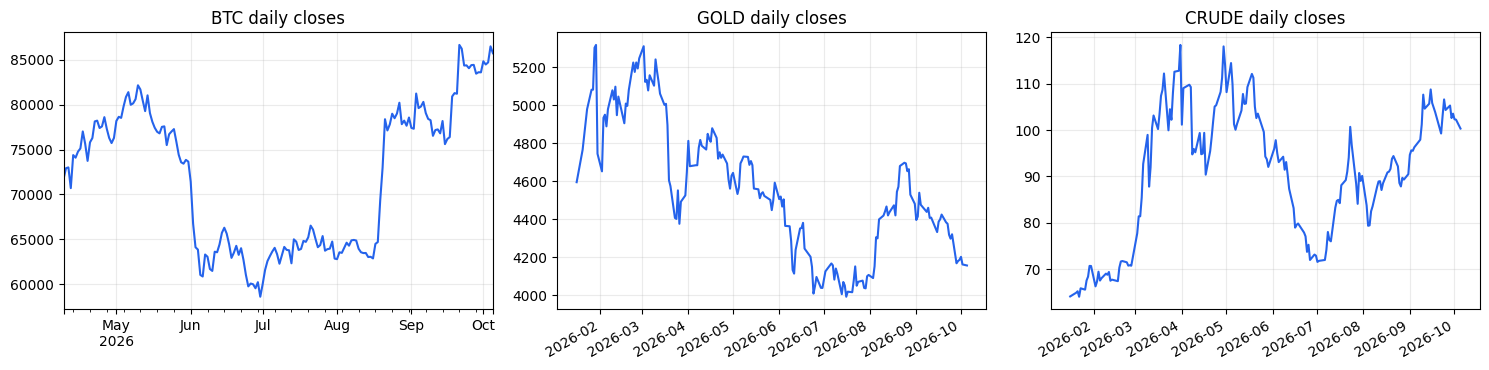

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for axis, (asset, data) in zip(axes, MARKET_DATA.items()):
    data.daily_closes.tail(180).plot(ax=axis, color="#2563eb", linewidth=1.5)
    axis.set_title(f"{asset} daily closes")
    axis.set_xlabel("")
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## EWMA volatility

Volatility measures how widely the underlying tends to move. A strike far from the current price is more reachable when volatility is high.

We first calculate daily log returns. EWMA then updates variance using:

`new variance = 0.94 x old variance + 0.06 x latest squared return`

Recent moves matter more, but older information fades gradually instead of disappearing at once. A lambda of 0.94 means yesterday's variance estimate keeps 94 percent of its weight and the newest squared return receives 6 percent. The direct weight of one particular observation falls by 6 percent each day. Its statistical half-life is about 11 days. This is a common starting value for daily market data, not a law of nature.

In [6]:
def ewma_volatility(
    prices: pd.Series,
    annualization: int,
    lookback_returns: int = LOOKBACK_RETURNS,
    decay: float = EWMA_LAMBDA,
) -> float:
    if not 0 < decay < 1:
        raise ValueError("EWMA decay must be between 0 and 1")
    clean = _clean_series(prices).tail(lookback_returns + 1)
    returns = np.log(clean / clean.shift(1)).dropna()
    if len(returns) < MIN_RETURNS:
        raise ValueError(f"Need at least {MIN_RETURNS} returns to estimate volatility")

    seed_count = min(20, max(2, len(returns) // 4))
    variance = float(returns.iloc[:seed_count].var(ddof=1))
    for value in returns.iloc[seed_count:]:
        variance = decay * variance + (1 - decay) * float(value) ** 2

    volatility = math.sqrt(max(variance, 0.0) * annualization)
    if not math.isfinite(volatility) or volatility <= 0:
        raise ValueError("Volatility estimate is invalid")
    return volatility


VOLATILITY = {
    asset: ewma_volatility(data.daily_closes, ASSET_CONFIG[asset]["annualization"])
    for asset, data in MARKET_DATA.items()
}

display(pd.DataFrame({"annualized_volatility": VOLATILITY}).T)

,BTC,GOLD,CRUDE
annualized_volatility,0.3638,0.2019,0.4029


## Fair probability

The model assumes the future price is lognormally distributed. In plain terms, it assumes percentage changes, rather than dollar changes, follow a bell-shaped pattern. The price stays above zero, small moves are more common than very large moves, and upside moves are not capped.

The core result is `N(d2)`, where `N` is the standard normal cumulative distribution. The model uses current price, strike, time to expiry, and annualized volatility.

This is a risk-neutral-style pricing probability. It gives a consistent price for the contract using market uncertainty and financing assumptions. It is not a real-world forecast based on news, momentum, supply and demand views, or estimated historical drift. Model 1 sets the risk-free rate and carry to zero, so current price, strike, time, and EWMA volatility drive the answer.

In [7]:
def to_utc_timestamp(value) -> pd.Timestamp:
    timestamp = pd.Timestamp(value)
    if timestamp.tzinfo is None:
        timestamp = timestamp.tz_localize("UTC")
    else:
        timestamp = timestamp.tz_convert("UTC")
    return timestamp


def time_to_expiry_years(expiry, valuation_time=None) -> float:
    expiry_utc = to_utc_timestamp(expiry)
    now_utc = to_utc_timestamp(valuation_time or pd.Timestamp.now(tz="UTC"))
    seconds = (expiry_utc - now_utc).total_seconds()
    if seconds <= 0:
        raise ValueError("Expiry must be after valuation time")
    return seconds / (365.0 * 24 * 60 * 60)


def digital_probability(
    spot: float,
    strike: float,
    time_years: float,
    volatility: float,
    risk_free_rate: float = RISK_FREE_RATE,
    carry: float = CARRY,
) -> float:
    values = [spot, strike, time_years, volatility]
    if not all(math.isfinite(value) and value > 0 for value in values):
        raise ValueError("Spot, strike, time, and volatility must be positive finite numbers")
    denominator = volatility * math.sqrt(time_years)
    d2 = (math.log(spot / strike) + (risk_free_rate - carry - 0.5 * volatility**2) * time_years) / denominator
    return min(1.0, max(0.0, NormalDist().cdf(d2)))

## Bid and ask policy

Fair value is the model midpoint. The bid is what the market maker pays to buy YES. The ask is what the market maker charges to sell YES.

For Model 1, the half-spread is fixed at two cents. If fair value is 0.60, the raw bid is 0.58 and the raw ask is 0.62. Bid rounds down to the nearest cent. Ask rounds up to the nearest cent.

A fixed spread is intentionally simple. It does not claim that every contract has the same trading risk. A more realistic policy would start with a base spread and add charges for stale data, unstable volatility, thin liquidity, a large requested order, inventory imbalance, and very short time to expiry. It would also keep the quote inside 0 and 1 and round outward to the exchange tick.

### Making the spread more realistic

The spread protects the market maker from being wrong. It should be wider when an error is more likely or more expensive.

- **Near expiry:** A small price move can cause a large probability change when little time remains. For example, with one hour left, a 0.1 percent BTC move could change fair value by about 10 cents for a contract near its strike. Widen the spread as expiry approaches, or stop quoting during the final minutes.
- **Stale price:** GOLD and CRUDE use the latest completed daily close. On a Monday morning, that price could be three days old. Widen the spread as the reference price gets older, and refuse to quote after a maximum age.
- **Price sensitivity:** Measure how much fair value changes after a 1 percent move in the underlying. Widen the spread when this change is large. Contracts near the current price are usually the most sensitive.
- **Volatility uncertainty:** If recent volatility estimates are changing sharply, the estimate is less reliable. Widen the spread to allow for that uncertainty.
- **Very low or high probabilities:** A fixed spread can be too large compared with the contract value. For example, a GOLD fair value near 0.03 can produce a quote such as 0.01 / 0.06. Use a partly proportional spread near 0 and 1, and set a minimum positive bid instead of posting a zero bid when the venue permits it.
- **Inventory:** If the market maker has already sold too many YES contracts, shift both bid and ask upward. This makes buying YES back more attractive and selling more YES less attractive.

A simple starting formula is:

`half-spread = base + a x sensitivity x price uncertainty + b x data age penalty`

The result should have a minimum and maximum. If data is too stale or expiry is too close, the safer action is to return no quote. This formula is a proposed improvement. Model 1 still uses the fixed two-cent half-spread below.

In [8]:
def _floor_to_tick(value: float, tick: float) -> float:
    return math.floor((value + 1e-12) / tick) * tick


def _ceil_to_tick(value: float, tick: float) -> float:
    return math.ceil((value - 1e-12) / tick) * tick


def make_bid_ask(
    fair_probability: float,
    half_spread: float = BASE_HALF_SPREAD,
    tick_size: float = TICK_SIZE,
) -> tuple[float, float]:
    if not 0 <= fair_probability <= 1:
        raise ValueError("Fair probability must be between 0 and 1")
    if half_spread <= 0 or tick_size <= 0:
        raise ValueError("Half-spread and tick size must be positive")

    raw_bid = max(0.0, fair_probability - half_spread)
    raw_ask = min(1.0, fair_probability + half_spread)
    bid = max(0.0, min(1.0, _floor_to_tick(raw_bid, tick_size)))
    ask = max(0.0, min(1.0, _ceil_to_tick(raw_ask, tick_size)))
    return round(bid, 10), round(ask, 10)


make_bid_ask(0.60)

(0.58, 0.62)

## Complete quote function

This is the main reusable function a reviewer can call. Reusable means the same function works for any supported asset, positive strike, and future expiry. It validates the inputs, selects the stored market data, estimates volatility, calculates fair probability, creates the bid and ask, and returns the inputs and intermediate results in one dictionary.

In [9]:
def quote(underlying: str, strike: float, expiry, valuation_time=None) -> dict:
    asset = underlying.upper()
    if asset not in ASSET_CONFIG:
        raise ValueError(f"Underlying must be one of {list(ASSET_CONFIG)}")
    if not math.isfinite(float(strike)) or float(strike) <= 0:
        raise ValueError("Strike must be a positive finite number")

    data = MARKET_DATA[asset]
    years = time_to_expiry_years(expiry, valuation_time)
    volatility = ewma_volatility(data.daily_closes, ASSET_CONFIG[asset]["annualization"])
    fair = digital_probability(data.spot, float(strike), years, volatility)
    bid, ask = make_bid_ask(fair)

    return {
        "underlying": asset,
        "reference_price": round(data.spot, 6),
        "strike": float(strike),
        "expiry_utc": to_utc_timestamp(expiry).isoformat(),
        "time_to_expiry_years": round(years, 6),
        "annualized_ewma_volatility": round(volatility, 6),
        "fair_probability": round(fair, 6),
        "bid": bid,
        "ask": ask,
        "half_spread": BASE_HALF_SPREAD,
        "data_source": data.source,
        "model": "lognormal_digital_with_ewma_volatility",
    }

### YES/NO market format

A binary market has two opposite outcomes. The fair YES price plus the fair NO price equals $1.00. Because real quotes include a spread, the two bids do not need to add to $1.00. Instead, the matching sides are **YES ask + NO bid = $1.00** and **YES bid + NO ask = $1.00**. A $0.00 bid means the model would normally post no buy order on that side.

In [10]:
def yes_no_quote_table(quote_result: dict) -> pd.DataFrame:
    """Convert one YES quote into a Polymarket-style YES/NO view."""
    yes_bid = quote_result['bid']
    yes_ask = quote_result['ask']
    fair_yes = quote_result['fair_probability']

    table = pd.DataFrame({
        'fair_price': [fair_yes, 1.0 - fair_yes],
        'bid': [yes_bid, 1.0 - yes_ask],
        'ask': [yes_ask, 1.0 - yes_bid],
    }, index=['YES', 'NO'])
    table.index.name = 'outcome'
    return table.round(4)

In [11]:
valuation_time = pd.Timestamp.now(tz="UTC")
example_expiry = pd.Timestamp("2027-01-01T00:00:00Z")
example_strikes = EXAMPLE_STRIKES.copy()
example_quotes = [
    quote(asset, strike, example_expiry, valuation_time)
    for asset, strike in example_strikes.items()
]

quote_table = pd.DataFrame(example_quotes).set_index("underlying")
display(quote_table[["reference_price", "strike", "annualized_ewma_volatility", "fair_probability", "bid", "ask", "data_source"]])

yes_no_tables = pd.concat(
    [yes_no_quote_table(result) for result in example_quotes],
    keys=[result['underlying'] for result in example_quotes],
    names=['underlying', 'outcome'],
)
display(yes_no_tables)

for result in example_quotes:
    fair_yes = result['fair_probability']
    print(f"{result['underlying']}: YES {fair_yes:.4f} + NO {1.0 - fair_yes:.4f} = 1.0000")

,reference_price,strike,annualized_ewma_volatility,fair_probability,bid,ask,data_source
underlying,,,,,,,
BTC,"86,058.6000","100,000.0000",0.3638,0.1744,0.1500,0.2000,Hyperliquid oraclePx and one-year completed BT...
GOLD,"4,156.7998","5,000.0000",0.2019,0.0268,0.0000,0.0500,Yahoo Finance GC=F one-year completed daily OHLC
CRUDE,100.3200,120.0000,0.4029,0.1557,0.1300,0.1800,Yahoo Finance BZ=F one-year completed daily OHLC


fair_price    bid    ask
underlying outcome                          
BTC        YES          0.1744 0.1500 0.2000
           NO           0.8256 0.8000 0.8500
GOLD       YES          0.0268 0.0000 0.0500
           NO           0.9732 0.9500 1.0000
CRUDE      YES          0.1557 0.1300 0.1800
           NO           0.8443 0.8200 0.8700

BTC: YES 0.1744 + NO 0.8256 = 1.0000
GOLD: YES 0.0268 + NO 0.9732 = 1.0000
CRUDE: YES 0.1557 + NO 0.8443 = 1.0000


## How strike changes probability

A higher strike is harder to exceed, so probability should fall as strike rises. This chart is both an explanation and a model sanity check.

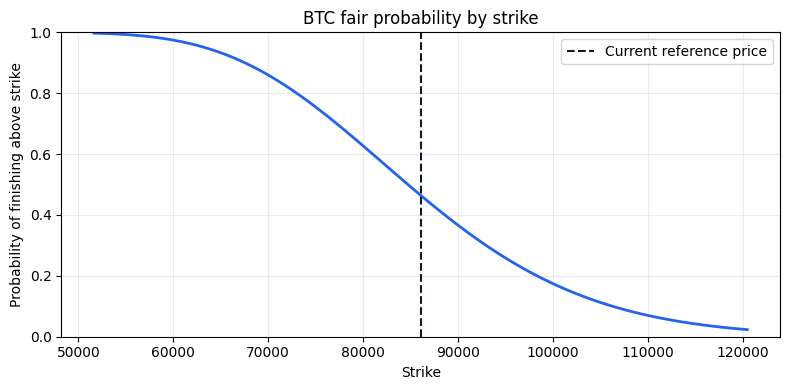

In [12]:
asset = "BTC"
spot = MARKET_DATA[asset].spot
volatility = VOLATILITY[asset]
years = time_to_expiry_years(example_expiry, valuation_time)
strikes = np.linspace(0.60 * spot, 1.40 * spot, 121)
probabilities = [digital_probability(spot, strike, years, volatility) for strike in strikes]

fig, axis = plt.subplots(figsize=(8, 4))
axis.plot(strikes, probabilities, color="#2563eb", linewidth=2)
axis.axvline(spot, color="#111827", linestyle="--", label="Current reference price")
axis.set_title("BTC fair probability by strike")
axis.set_xlabel("Strike")
axis.set_ylabel("Probability of finishing above strike")
axis.set_ylim(0, 1)
axis.grid(alpha=0.25)
axis.legend()
plt.tight_layout()
plt.show()

## Settlement methods

BTC uses a one-minute TWAP. Each captured oracle price applies until the next observation. The first observation must cover the start of the window, and no observation gap may exceed the configured maximum.

GOLD and CRUDE use the Yahoo Finance daily Close on the expiry trading date. If the date is not a trading day, the latest close before that date is used.

These functions demonstrate the contract rules. The pricing task itself only requires bid and ask quotes.

In [13]:
def btc_oracle_twap(
    observations: pd.DataFrame,
    expiry,
    window_seconds: int = 60,
    max_gap_seconds: int = 10,
) -> float:
    required = {"observed_at", "price"}
    if not required.issubset(observations.columns):
        raise ValueError(f"Observations need columns: {sorted(required)}")

    frame = observations[list(required)].copy()
    frame["observed_at"] = pd.to_datetime(frame["observed_at"], utc=True)
    frame["price"] = pd.to_numeric(frame["price"], errors="coerce")
    frame = frame.dropna().sort_values("observed_at").drop_duplicates("observed_at", keep="last")
    frame = frame[np.isfinite(frame["price"]) & (frame["price"] > 0)]

    end = to_utc_timestamp(expiry)
    start = end - pd.Timedelta(seconds=window_seconds)
    seed = frame[frame["observed_at"] <= start].tail(1)
    inside = frame[(frame["observed_at"] > start) & (frame["observed_at"] < end)]
    if seed.empty:
        raise ValueError("No oracle observation covers the start of the TWAP window")

    seed_age = (start - seed.iloc[0]["observed_at"]).total_seconds()
    if seed_age > max_gap_seconds:
        raise ValueError("The observation at the start of the TWAP window is stale")

    event_times = [start] + inside["observed_at"].tolist()
    event_prices = [float(seed.iloc[0]["price"])] + inside["price"].astype(float).tolist()
    next_times = event_times[1:] + [end]
    durations = np.array([(next_time - event_time).total_seconds() for event_time, next_time in zip(event_times, next_times)])
    if len(durations) == 0 or durations.max() > max_gap_seconds or not math.isclose(durations.sum(), window_seconds):
        raise ValueError("Oracle observations do not provide valid TWAP coverage")
    return float(np.average(event_prices, weights=durations))


def daily_close_on_or_before(prices: pd.Series, expiry_date) -> tuple[pd.Timestamp, float]:
    clean = _clean_series(prices)
    target = to_utc_timestamp(expiry_date).date()
    eligible = clean[[timestamp.date() <= target for timestamp in clean.index]]
    if eligible.empty:
        raise ValueError("No daily close exists on or before the expiry date")
    return pd.Timestamp(eligible.index[-1]), float(eligible.iloc[-1])


def binary_payout(settlement_price: float, strike: float) -> float:
    return 1.0 if settlement_price > strike else 0.0

In [14]:
def capture_hyperliquid_oracle(duration_seconds: int = 60, poll_seconds: int = 3) -> pd.DataFrame:
    """Capture live BTC oracle observations. Start this before the settlement window."""
    rows = []
    deadline = time.monotonic() + duration_seconds
    while time.monotonic() < deadline:
        price, observed_at = fetch_hyperliquid_oracle()
        rows.append({"observed_at": observed_at, "price": price})
        time.sleep(poll_seconds)
    return pd.DataFrame(rows)


demo_expiry = pd.Timestamp.now(tz="UTC").floor("s")
demo_times = pd.date_range(demo_expiry - pd.Timedelta(seconds=63), demo_expiry - pd.Timedelta(seconds=3), freq="3s")
demo_observations = pd.DataFrame(
    {
        "observed_at": demo_times,
        "price": MARKET_DATA["BTC"].spot + np.linspace(-20, 25, len(demo_times)),
    }
)
demo_btc_twap = btc_oracle_twap(demo_observations, demo_expiry)
gold_close_date, gold_close = daily_close_on_or_before(MARKET_DATA["GOLD"].daily_closes, MARKET_DATA["GOLD"].daily_closes.index[-1])
crude_close_date, crude_close = daily_close_on_or_before(MARKET_DATA["CRUDE"].daily_closes, MARKET_DATA["CRUDE"].daily_closes.index[-1])

display(pd.DataFrame(
    [
        {"underlying": "BTC", "settlement_method": "60-second oracle TWAP", "example_value": demo_btc_twap},
        {"underlying": "GOLD", "settlement_method": f"GC=F daily Close on {gold_close_date.date()}", "example_value": gold_close},
        {"underlying": "CRUDE", "settlement_method": f"BZ=F daily Close on {crude_close_date.date()}", "example_value": crude_close},
    ]
).set_index("underlying"))

,settlement_method,example_value
underlying,,
BTC,60-second oracle TWAP,"86,062.2250"
GOLD,GC=F daily Close on 2026-10-05,"4,156.7998"
CRUDE,BZ=F daily Close on 2026-10-05,100.3200


## Sanity checks

These assertions are small tests inside the notebook. If the cell finishes successfully, the core behavior is consistent with the written rules.

In [15]:
assert make_bid_ask(0.60) == (0.58, 0.62)
assert binary_payout(101.0, 100.0) == 1.0
assert binary_payout(100.0, 100.0) == 0.0
assert binary_payout(99.0, 100.0) == 0.0
assert 0.0 <= make_bid_ask(0.001)[0] <= make_bid_ask(0.001)[1] <= 1.0
assert 0.0 <= make_bid_ask(0.999)[0] <= make_bid_ask(0.999)[1] <= 1.0
assert all(earlier >= later for earlier, later in zip(probabilities, probabilities[1:]))
assert math.isclose(btc_oracle_twap(
    pd.DataFrame({"observed_at": demo_times, "price": 100.0}), demo_expiry
), 100.0)

for result in example_quotes:
    assert 0 <= result["bid"] <= result["fair_probability"] <= result["ask"] <= 1
    assert math.isfinite(result["annualized_ewma_volatility"])

print("All sanity checks passed.")

All sanity checks passed.


## Limitations and sensible next steps

- The model does not assume any upward or downward real-world drift. BTC is not given a positive expected return just because it has risen historically. The result is a risk-neutral-style pricing probability, not a real-world forecast.
- The future $1 payout is not discounted. This matches the current zero-rate assumption, but probability and present value would differ if interest rates were included.
- One EWMA volatility estimate is used for the entire time to expiry. Future volatility can change, and lambda 0.94 and the 180-return lookback have not been separately calibrated for each asset.
- Historical volatility is not implied volatility. It does not include the market's current option pricing or volatility skew.
- Lognormal prices understate jumps and fat tails. This matters for BTC and crude oil.
- Risk-free rate and carry are zero. Commodity storage, convenience yield, and futures curves are ignored.
- `GC=F` and `BZ=F` are rolling futures. A roll can create an artificial return in the history.
- Yahoo Finance is appropriate for this demonstration, not for production settlement.
- Hyperliquid daily candles are trade candles, while BTC settlement uses `oraclePx`. This creates a small benchmark mismatch in volatility estimation.
- The two-cent half-spread is a clear policy choice, not an optimized market-making spread.
- Near-expiry risk, stale-data penalties, liquidity, order size, and inventory are not modeled.
- Failed live requests use clearly labeled sample data so the notebook can still be demonstrated. A real trading system must return no quote instead of trading from sample data.
- Model 2 will need a joint distribution and a dependence assumption between the two assets.

## Final summary

Model 1 is deliberately small. It converts an underlying, strike, and expiry into an explainable probability, then places a simple two-sided quote around that probability. Data retrieval, volatility, fair value, spread, and settlement are kept separate so each assumption can be replaced without rewriting the whole model.